In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

<h3><b>1. Advertising</b></h3>

In [5]:
df = pd.read_csv(r"E:\Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (200, 4)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [10]:
df = df.fillna(df.median(numeric_only=True))

In [11]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [12]:
print("Duplicate records before removing:", df.duplicated().sum())

Duplicate records before removing: 0


In [13]:
df = df.drop_duplicates()

In [14]:
print("Duplicate records after removing:", df.duplicated().sum())

Duplicate records after removing: 0


In [15]:
print(df.dtypes)

TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object


In [16]:
df = df.apply(pd.to_numeric, errors='coerce')

In [17]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


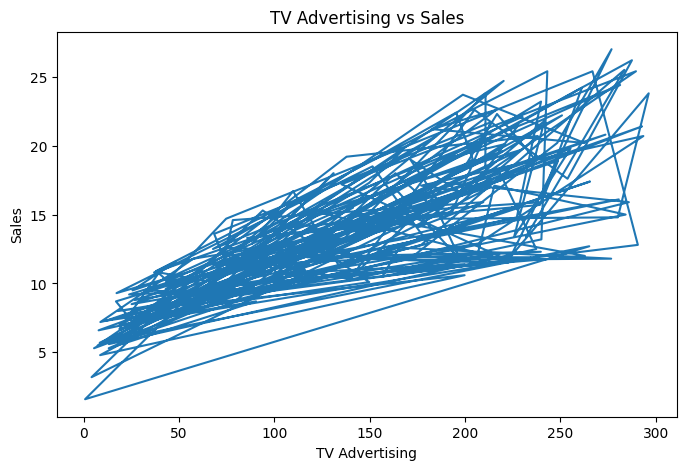

In [19]:
plt.figure(figsize=(8,5))
plt.plot(df["TV"], df["sales"])
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")
plt.show()

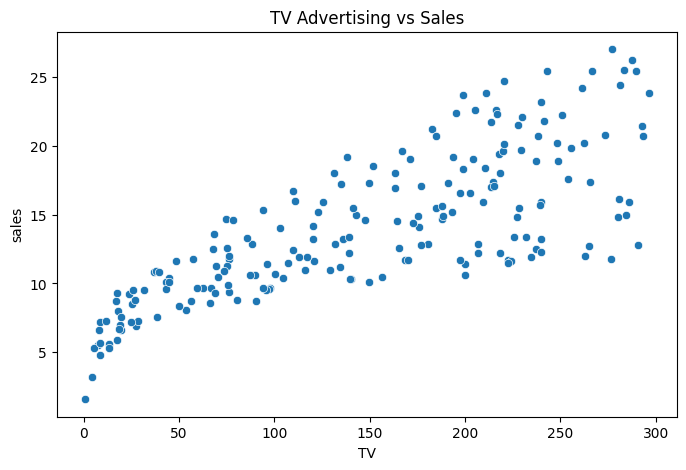

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="TV", y="sales", data=df)
plt.title("TV Advertising vs Sales")
plt.show()

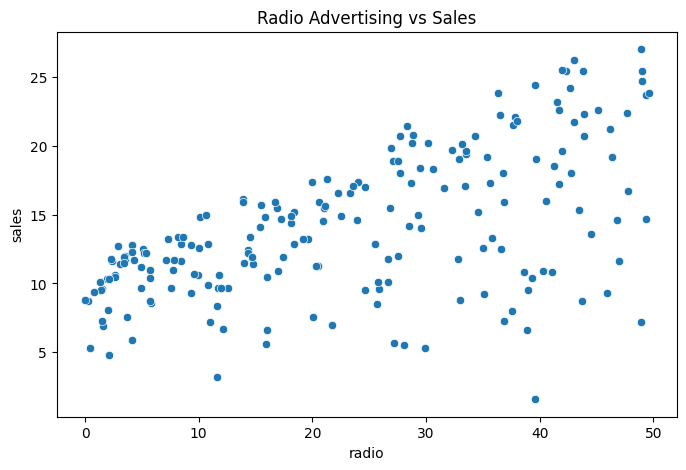

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="radio", y="sales", data=df)
plt.title("Radio Advertising vs Sales")
plt.show()

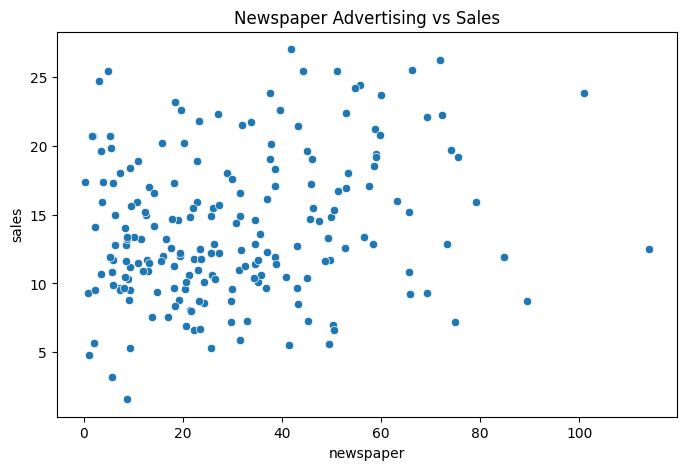

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="newspaper", y="sales", data=df)
plt.title("Newspaper Advertising vs Sales")
plt.show()

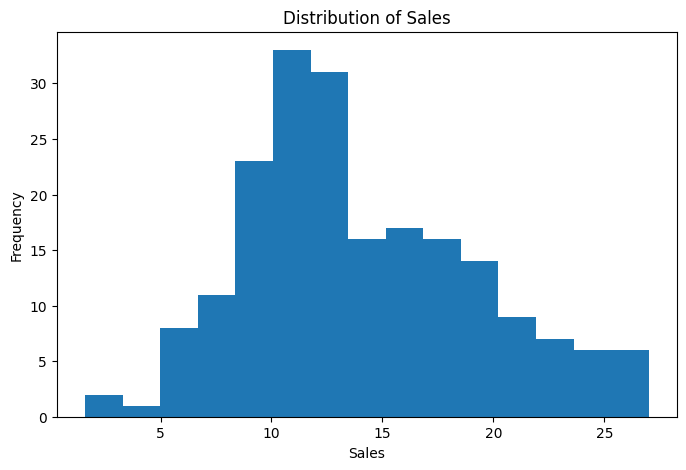

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df["sales"], bins=15)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")
plt.show()

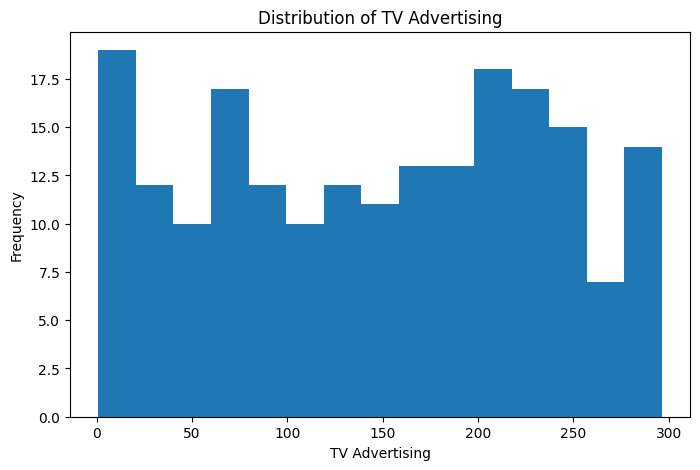

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df["TV"], bins=15)
plt.xlabel("TV Advertising")
plt.ylabel("Frequency")
plt.title("Distribution of TV Advertising")
plt.show()

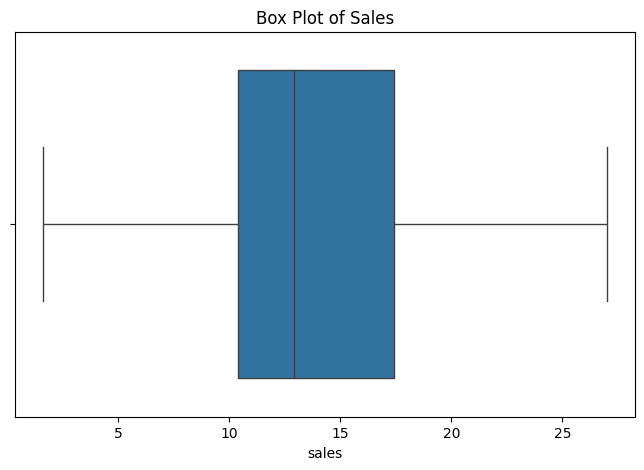

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["sales"])
plt.title("Box Plot of Sales")
plt.show()

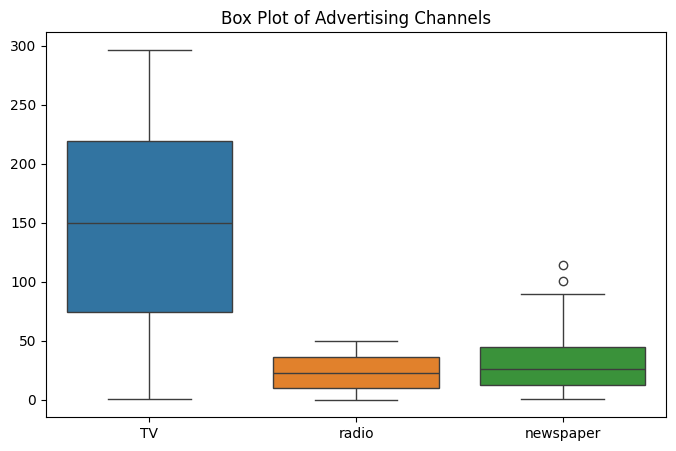

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["TV", "radio", "newspaper"]])
plt.title("Box Plot of Advertising Channels")
plt.show()

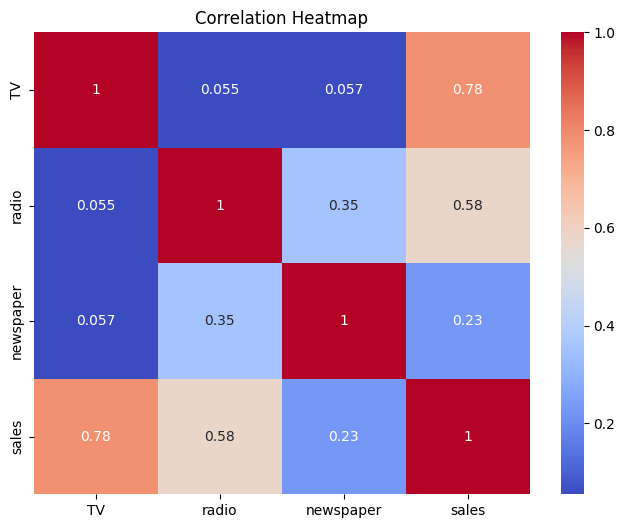

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

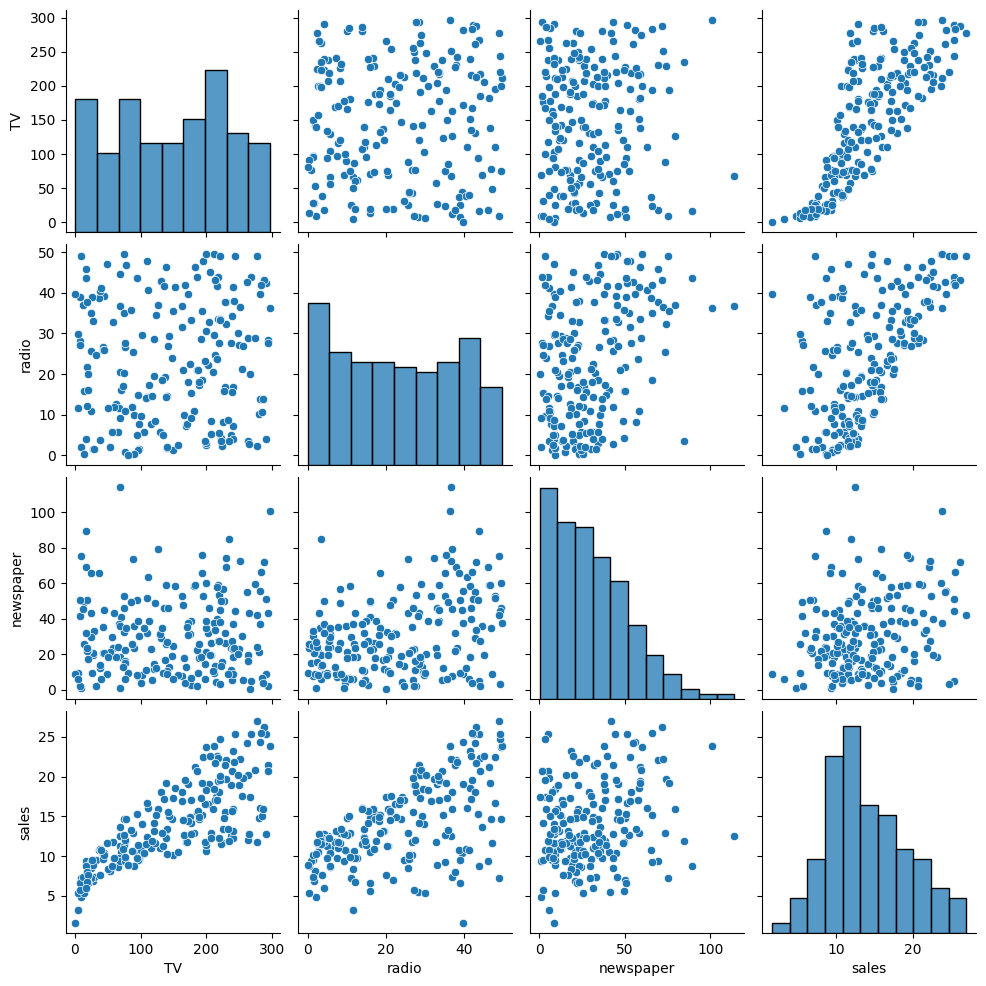

In [28]:
sns.pairplot(df)
plt.show()

In [29]:
X = df.drop("sales", axis=1)

y = df["sales"]

In [30]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [31]:
y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64

In [32]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (200, 3)
y Shape: (200,)


In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [34]:
X_scaled[:5]

array([[ 0.96985227,  0.98152247,  1.77894547],
       [-1.19737623,  1.08280781,  0.66957876],
       [-1.51615499,  1.52846331,  1.78354865],
       [ 0.05204968,  1.21785493,  1.28640506],
       [ 0.3941822 , -0.84161366,  1.28180188]])

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)


<h3><b>2. Fabric Data</b></h3>

In [39]:
df = pd.read_excel(r"E:\Fabric data.xlsx")

df.head()

,Fabric_length
0,151.2
1,160.3
2,147.5
3,149.2
4,159.2


In [40]:
print("Shape:", df.shape)

Shape: (25, 1)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Fabric_length  25 non-null     float64
dtypes: float64(1)
memory usage: 332.0 bytes


In [42]:
df.describe()

,Fabric_length
count,25.00000
mean,155.06400
std,5.64047
min,147.50000
25%,149.20000
50%,155.20000
75%,158.40000
max,167.50000


In [43]:
df.isnull().sum()

Fabric_length    0
dtype: int64

In [44]:
df["Fabric_length"] = df["Fabric_length"].fillna(
    df["Fabric_length"].median()
)

In [45]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 2


In [46]:
df = df.drop_duplicates()

In [47]:
print(df.dtypes)

Fabric_length    float64
dtype: object


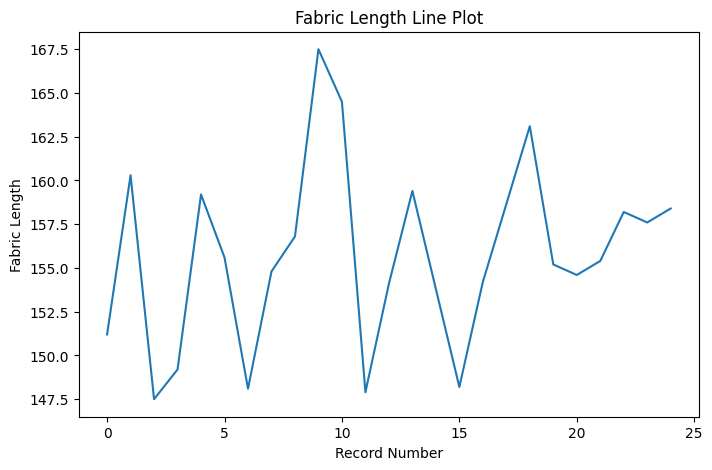

In [48]:
plt.figure(figsize=(8,5))
plt.plot(df.index, df["Fabric_length"])
plt.xlabel("Record Number")
plt.ylabel("Fabric Length")
plt.title("Fabric Length Line Plot")
plt.show()

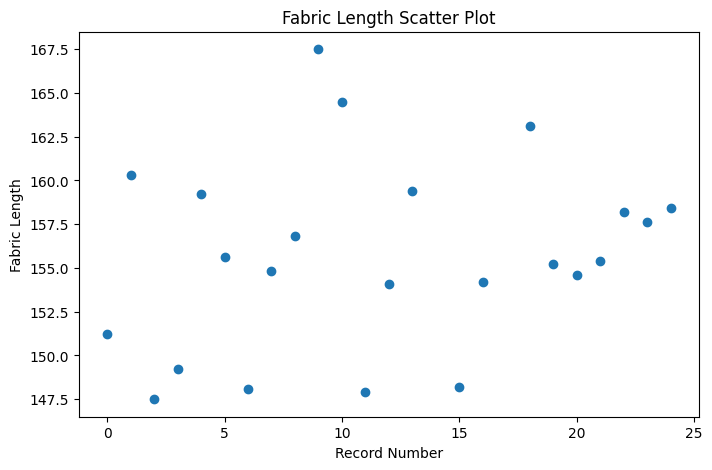

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(df.index, df["Fabric_length"])
plt.xlabel("Record Number")
plt.ylabel("Fabric Length")
plt.title("Fabric Length Scatter Plot")
plt.show()

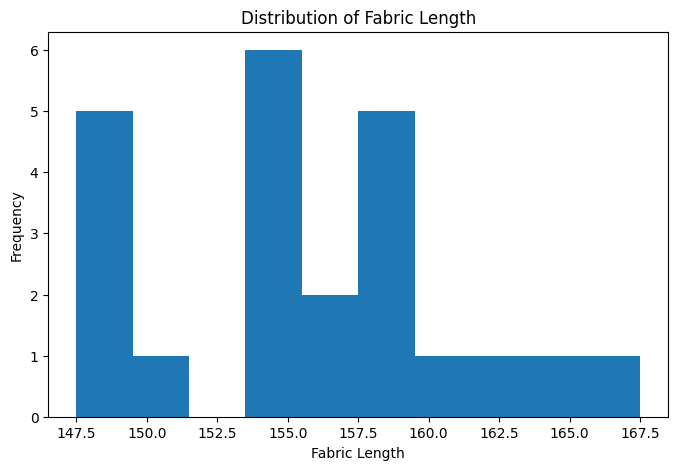

In [50]:
plt.figure(figsize=(8,5))
plt.hist(df["Fabric_length"], bins=10)
plt.xlabel("Fabric Length")
plt.ylabel("Frequency")
plt.title("Distribution of Fabric Length")
plt.show()

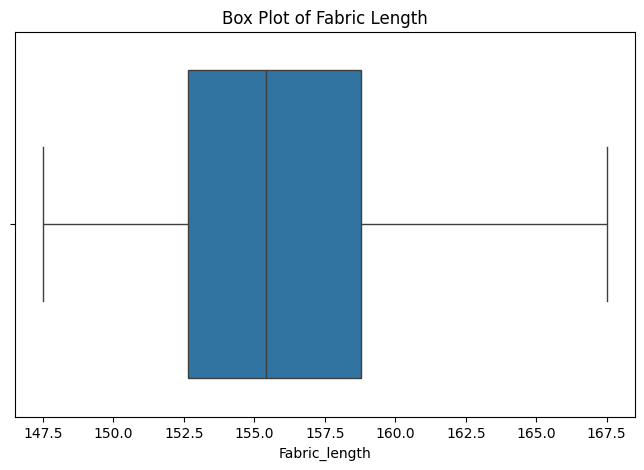

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fabric_length"])
plt.title("Box Plot of Fabric Length")
plt.show()

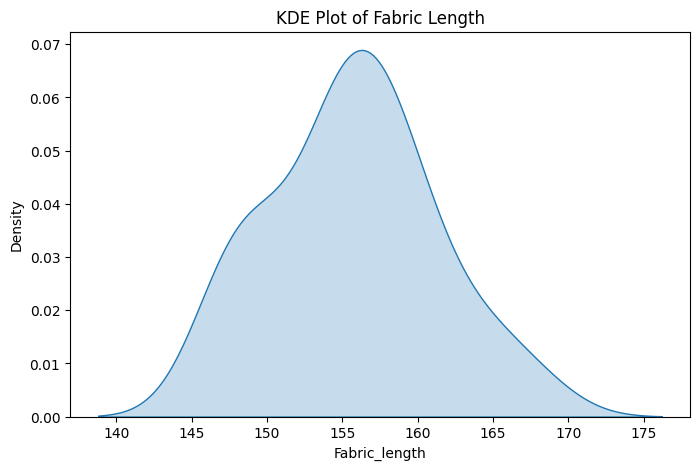

In [52]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["Fabric_length"], fill=True)
plt.title("KDE Plot of Fabric Length")
plt.show()

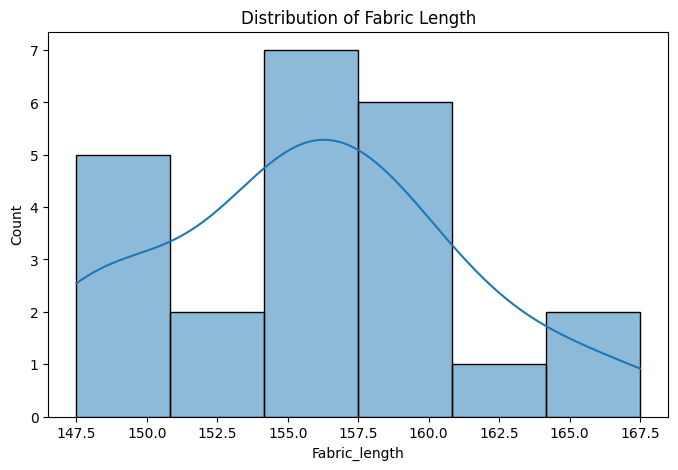

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fabric_length"], kde=True)
plt.title("Distribution of Fabric Length")
plt.show()

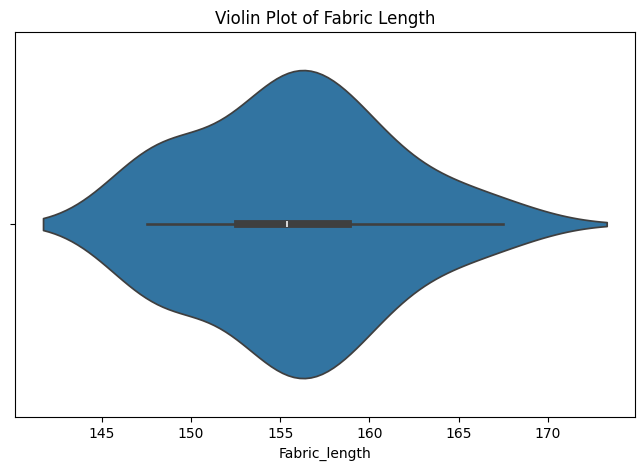

In [54]:
plt.figure(figsize=(8,5))
sns.violinplot(x=df["Fabric_length"])
plt.title("Violin Plot of Fabric Length")
plt.show()

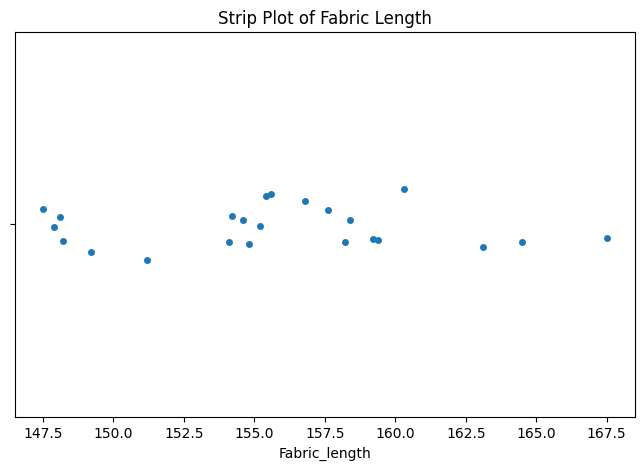

In [55]:
plt.figure(figsize=(8,5))
sns.stripplot(x=df["Fabric_length"])
plt.title("Strip Plot of Fabric Length")
plt.show()

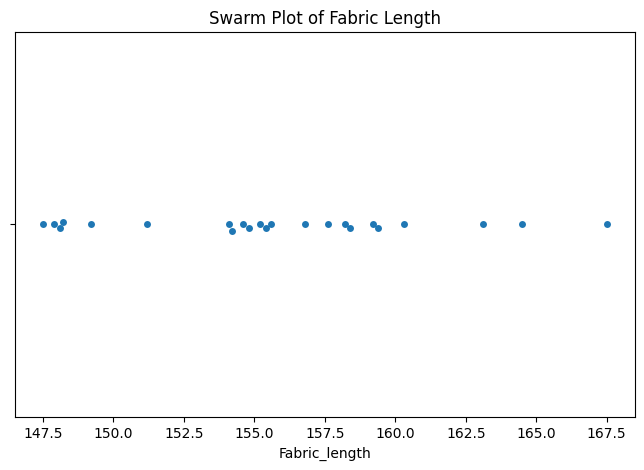

In [56]:
plt.figure(figsize=(8,5))
sns.swarmplot(x=df["Fabric_length"])
plt.title("Swarm Plot of Fabric Length")
plt.show()

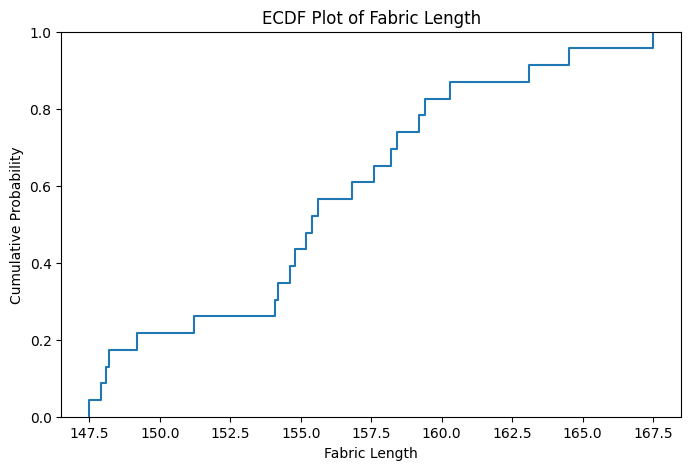

In [57]:
plt.figure(figsize=(8,5))
sns.ecdfplot(df["Fabric_length"])
plt.xlabel("Fabric Length")
plt.ylabel("Cumulative Probability")
plt.title("ECDF Plot of Fabric Length")
plt.show()

In [58]:
X = df[["Fabric_length"]]
y = df["Fabric_length"]

<h3><b>3. HomePrices </b></h3>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [61]:
df = pd.read_csv(r"E:\homeprices.csv")

df.head()

,town,area,price
0,Chennai,2600,5500000
1,Chennai,3000,5650000
2,Chennai,3200,6100000
3,Chennai,3600,6800000
4,Bangalore,2600,5850000


In [62]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 12
Number of Columns: 3


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   town    12 non-null     object
 1   area    12 non-null     int64 
 2   price   12 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 420.0+ bytes


In [64]:
df.describe()

,area,price
count,12.000000,1.200000e+01
mean,3075.000000,6.212500e+06
std,391.094037,5.214163e+05
min,2600.000000,5.500000e+06
25%,2750.000000,5.825000e+06
50%,3050.000000,6.125000e+06
75%,3375.000000,6.575000e+06
max,3600.000000,7.100000e+06


In [65]:
df.isnull().sum()

town     0
area     0
price    0
dtype: int64

In [67]:
df.isnull().sum()

town     0
area     0
price    0
dtype: int64

In [68]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [69]:
df = df.drop_duplicates()

In [71]:
print("Duplicate records after removal:", df.duplicated().sum())

Duplicate records after removal: 0


In [72]:
df["town"] = df["town"].astype(str)
df["area"] = pd.to_numeric(df["area"], errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [73]:
df.dtypes

town     object
area      int64
price     int64
dtype: object

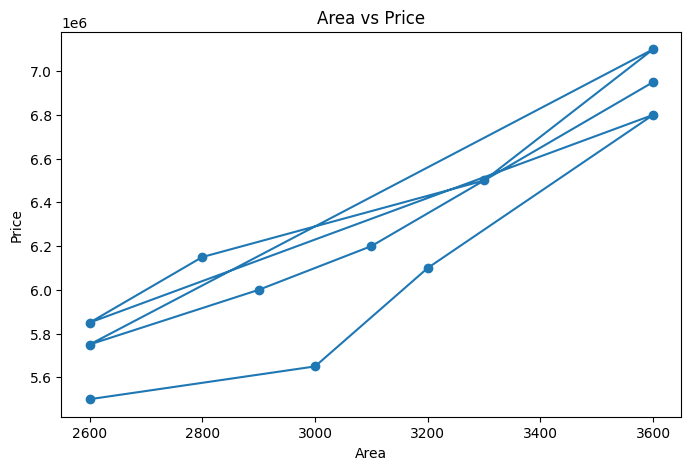

In [74]:
plt.figure(figsize=(8,5))
plt.plot(df["area"], df["price"], marker="o")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

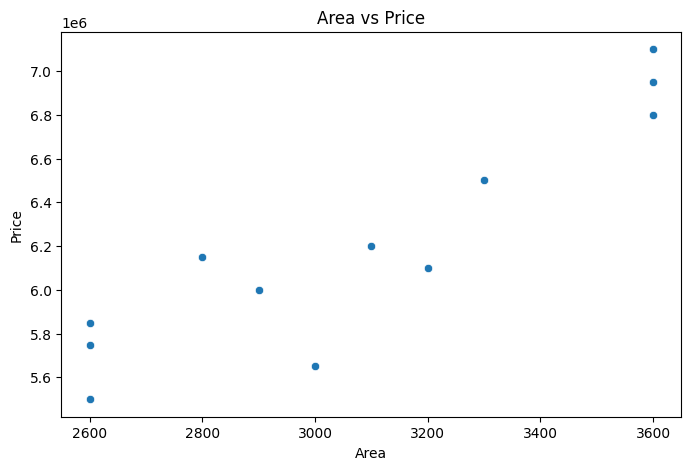

In [75]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="area", y="price", data=df)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

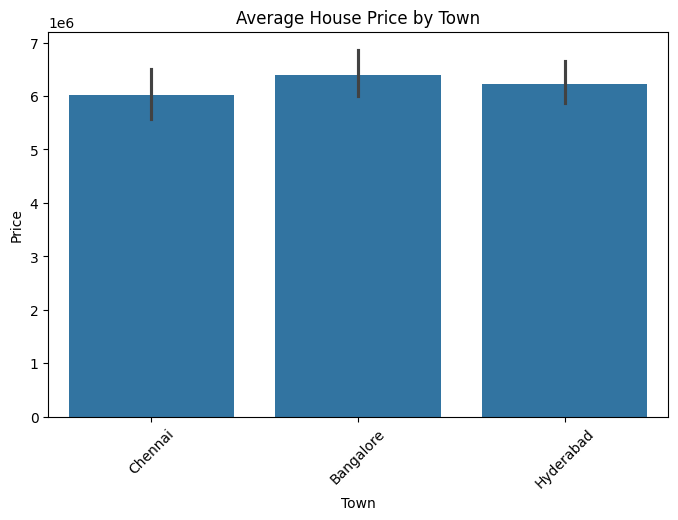

In [76]:
plt.figure(figsize=(8,5))
sns.barplot(x="town", y="price", data=df)
plt.xlabel("Town")
plt.ylabel("Price")
plt.title("Average House Price by Town")
plt.xticks(rotation=45)
plt.show()

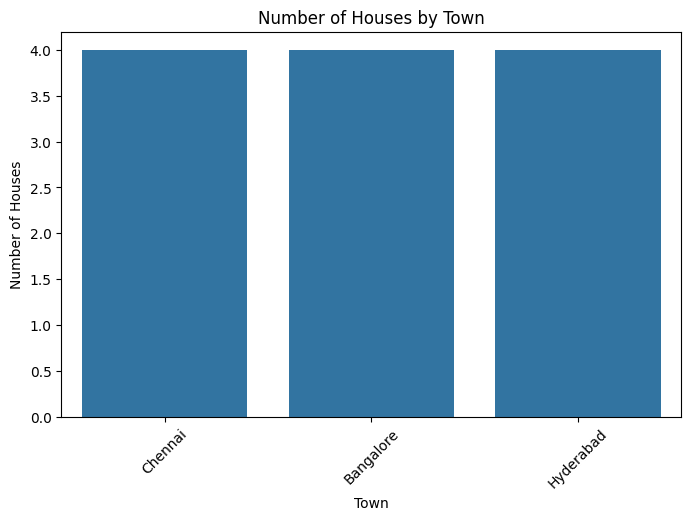

In [77]:
plt.figure(figsize=(8,5))
sns.countplot(x="town", data=df)
plt.xlabel("Town")
plt.ylabel("Number of Houses")
plt.title("Number of Houses by Town")
plt.xticks(rotation=45)
plt.show()

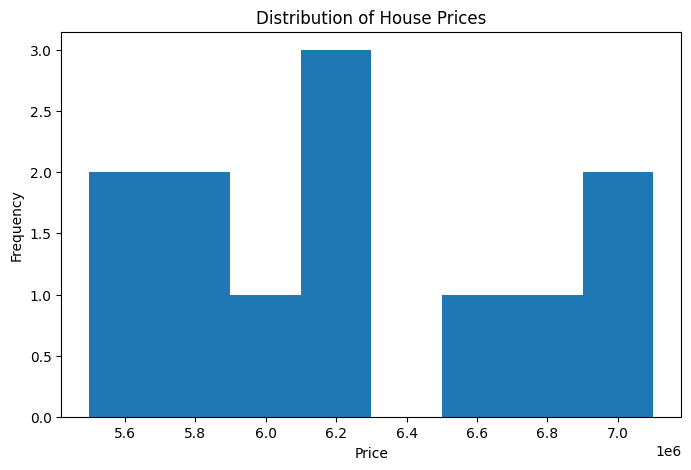

In [78]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=8)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

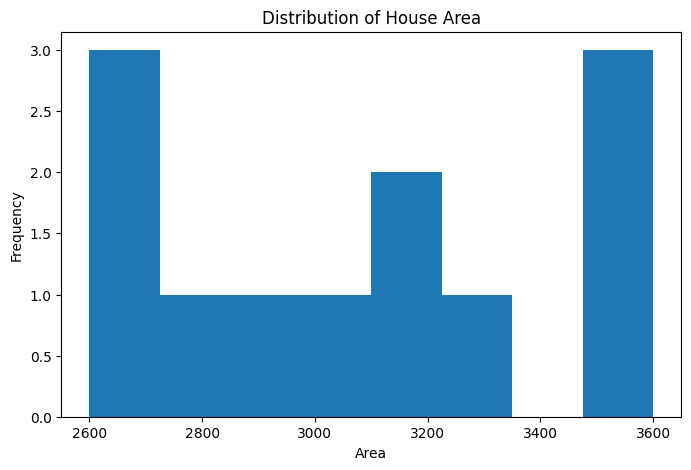

In [79]:
plt.figure(figsize=(8,5))
plt.hist(df["area"], bins=8)
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.title("Distribution of House Area")
plt.show()

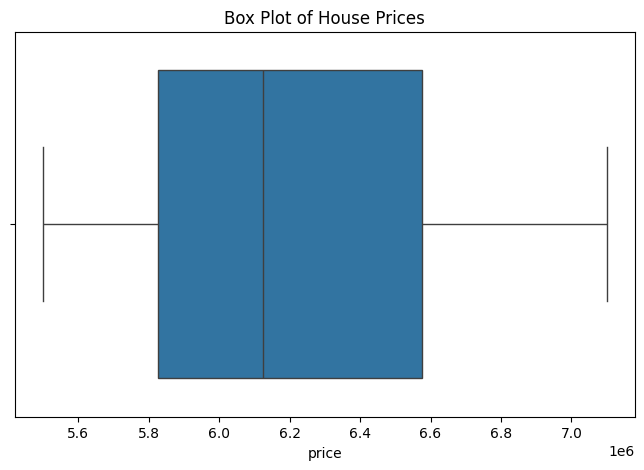

In [80]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Box Plot of House Prices")
plt.show()

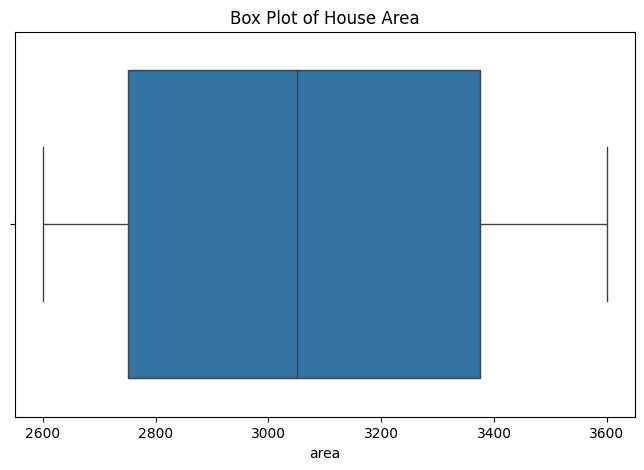

In [81]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["area"])
plt.title("Box Plot of House Area")
plt.show()

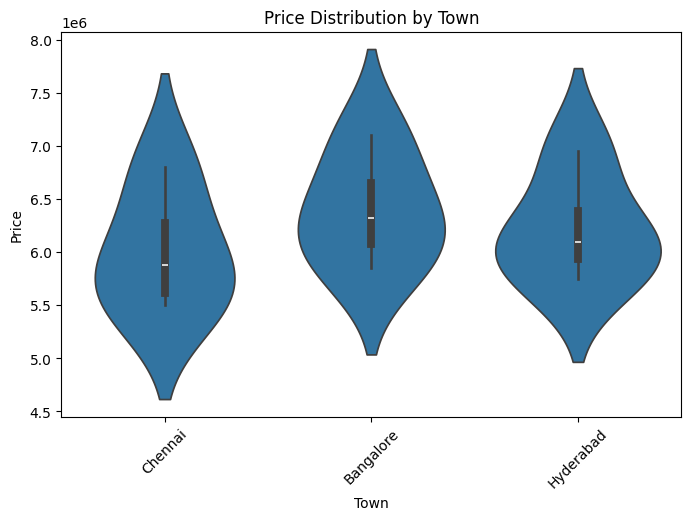

In [82]:
plt.figure(figsize=(8,5))
sns.violinplot(x="town", y="price", data=df)
plt.xlabel("Town")
plt.ylabel("Price")
plt.title("Price Distribution by Town")
plt.xticks(rotation=45)
plt.show()

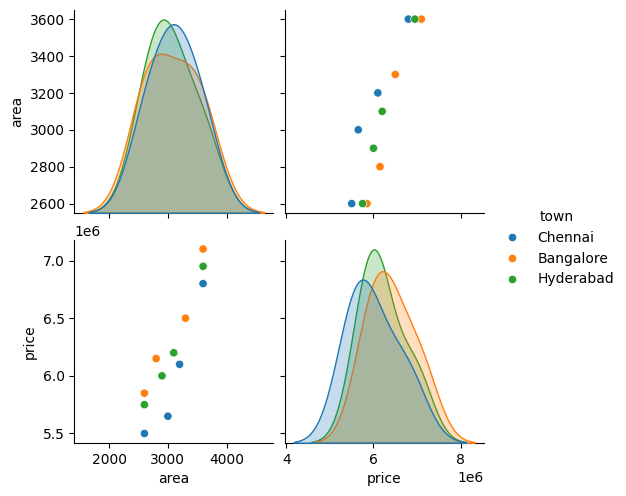

In [83]:
sns.pairplot(df, hue="town")
plt.show()

In [84]:
X = df.drop("price", axis=1)

y = df["price"]

In [85]:
print("X:")
print(X.head())

X:
        town  area
0    Chennai  2600
1    Chennai  3000
2    Chennai  3200
3    Chennai  3600
4  Bangalore  2600


In [86]:
print("y:")
print(y.head())

y:
0    5500000
1    5650000
2    6100000
3    6800000
4    5850000
Name: price, dtype: int64


In [87]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (12, 2)
y Shape: (12,)


In [89]:
categorical_features = ["town"]
numerical_features = ["area"]

In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [91]:
X_transformed = preprocessor.fit_transform(X)

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed,
    y,
    test_size=0.2,
    random_state=42
)

In [93]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9, 4)
X_test shape: (3, 4)
y_train shape: (9,)
y_test shape: (3,)


<h3><b>4. Mushroom</b></h3>

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [95]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 12
Number of Columns: 3


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   town    12 non-null     object
 1   area    12 non-null     int64 
 2   price   12 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 420.0+ bytes


In [97]:
df.describe(include="all")

,town,area,price
count,12,12.000000,1.200000e+01
unique,3,NaN,NaN
top,Chennai,NaN,NaN
freq,4,NaN,NaN
mean,NaN,3075.000000,6.212500e+06
std,NaN,391.094037,5.214163e+05
min,NaN,2600.000000,5.500000e+06
25%,NaN,2750.000000,5.825000e+06
50%,NaN,3050.000000,6.125000e+06
75%,NaN,3375.000000,6.575000e+06


In [98]:
df.isnull().sum()

town     0
area     0
price    0
dtype: int64

In [99]:
df = df.replace("?", np.nan)

In [100]:
df.isnull().sum()

town     0
area     0
price    0
dtype: int64

In [101]:
for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

In [102]:
df.isnull().sum().sum()

np.int64(0)

In [103]:
print("Duplicate records before removal:", df.duplicated().sum())

Duplicate records before removal: 0


In [104]:
df = df.drop_duplicates()

In [105]:
print("Duplicate records after removal:", df.duplicated().sum())

Duplicate records after removal: 0


In [106]:
for column in df.columns:
    df[column] = df[column].astype("category")

In [107]:
df.dtypes

town     category
area     category
price    category
dtype: object

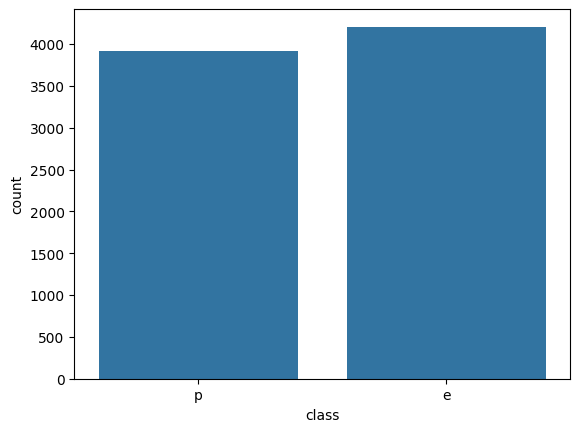

(8124, 22)
(8124,)


In [110]:
df = pd.read_csv(r"E:\mushrooms.csv")

df.columns = df.columns.str.strip()

target = df.columns[0]

sns.countplot(x=target, data=df)
plt.show()

X = df.drop(target, axis=1)
y = df[target]

print(X.shape)
print(y.shape)

In [111]:
# Categorical columns
categorical_features = X.columns.tolist()

# One-Hot Encoding
encoder = OneHotEncoder(handle_unknown="ignore")
X_encoded = encoder.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (6499, 117)
X_test: (1625, 117)
y_train: (6499,)
y_test: (1625,)


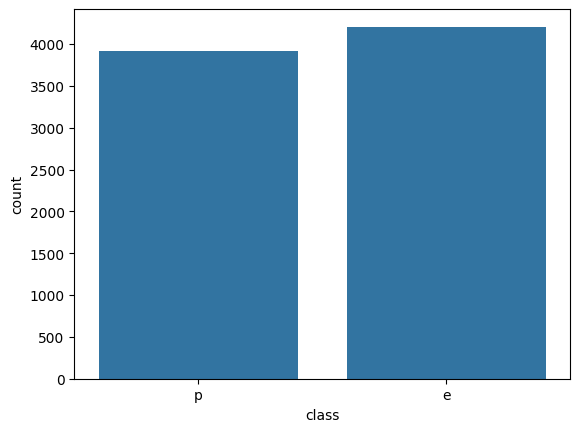

In [125]:
#1. Target Distribution
sns.countplot(x=df.columns[0], data=df)
plt.show()

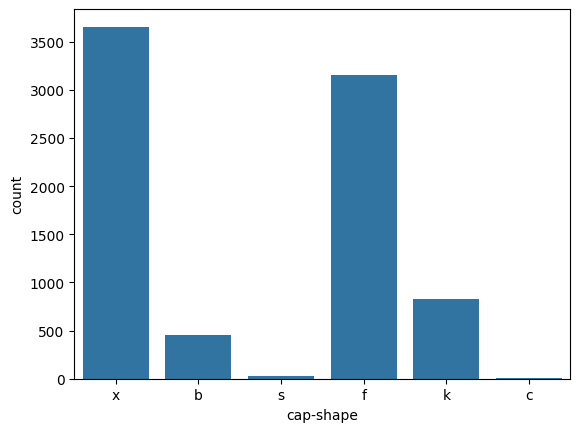

In [126]:
# 2. Cap Shape
sns.countplot(x=df.columns[1], data=df)
plt.show()

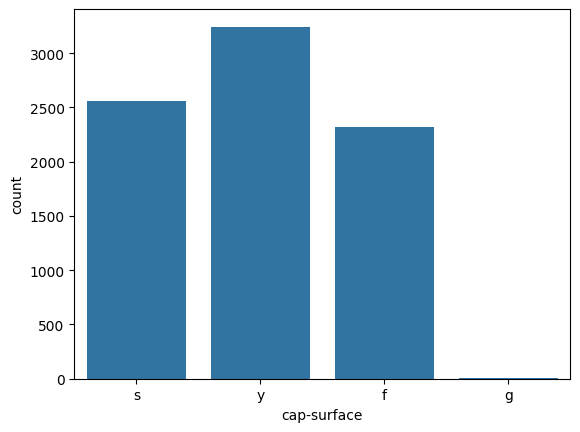

In [127]:
# 3. Cap Surface
sns.countplot(x=df.columns[2], data=df)
plt.show()

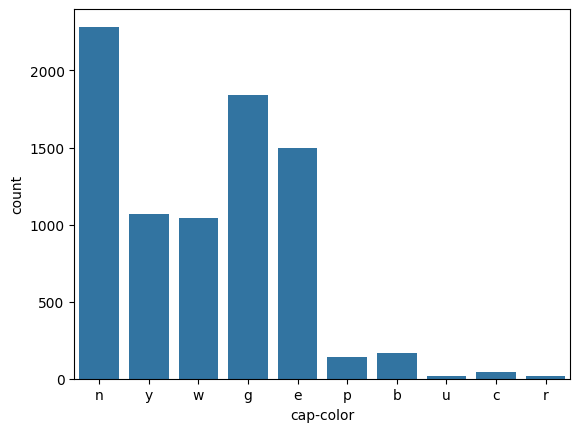

In [128]:
# 4. Cap Color
sns.countplot(x=df.columns[3], data=df)
plt.show()

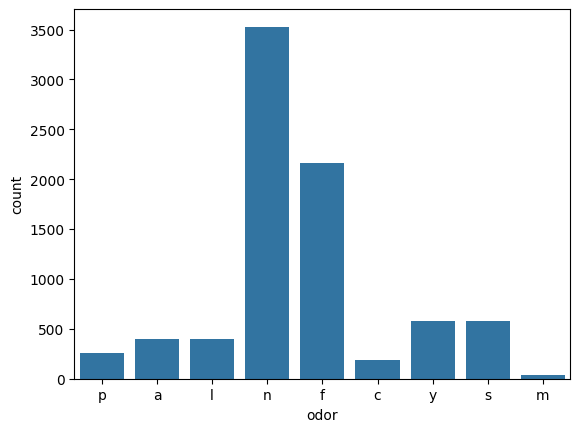

In [129]:
# 5. Odor
sns.countplot(x=df.columns[5], data=df)
plt.show()

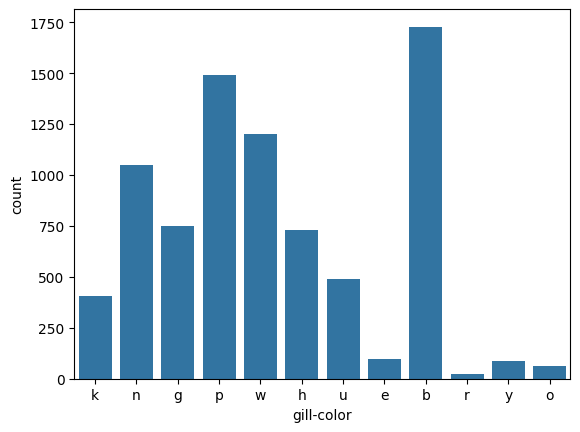

In [130]:
# 6. Gill Color
sns.countplot(x=df.columns[9], data=df)
plt.show()

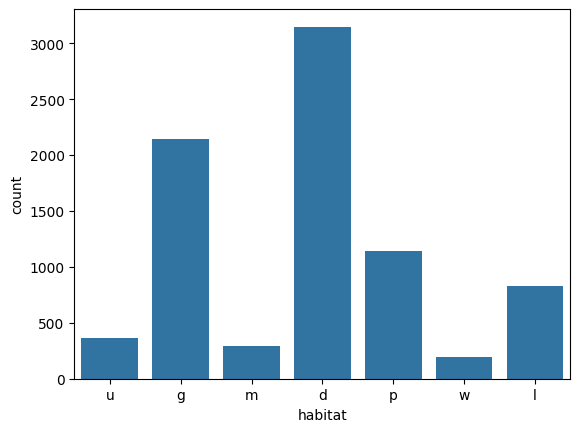

In [131]:
# 7. Habitat
sns.countplot(x=df.columns[-1], data=df)
plt.show()

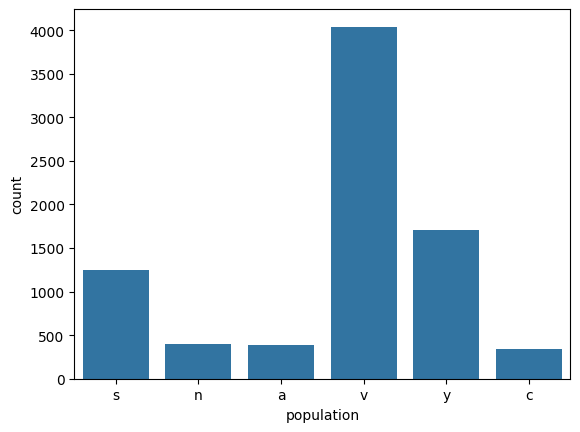

In [124]:
# 8. Population
sns.countplot(x=df.columns[-2], data=df)
plt.show()

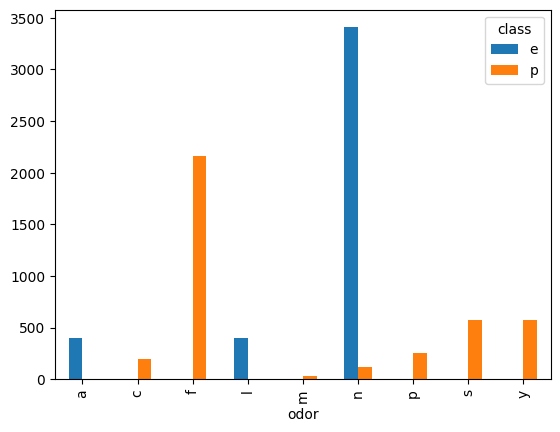

In [123]:
#9. Stacked Bar Plot
pd.crosstab(df.iloc[:, 5], df.iloc[:, 0]).plot(kind="bar")
plt.show()

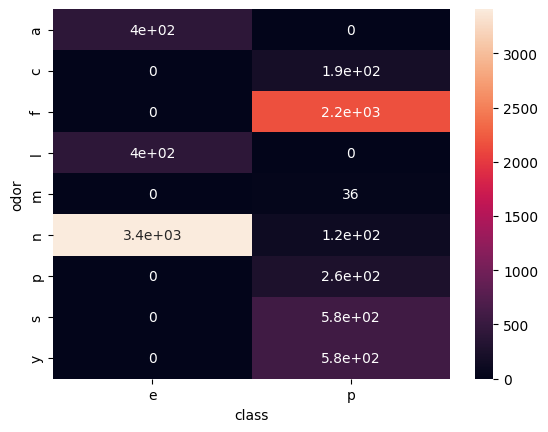

In [122]:
#10. Heatmap
sns.heatmap(pd.crosstab(df.iloc[:, 5], df.iloc[:, 0]), annot=True)
plt.show()

In [132]:
X = df.drop("class", axis=1)

y = df["class"]

In [133]:
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [134]:
y.head()

0    p
1    e
2    e
3    p
4    e
Name: class, dtype: object

In [135]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (8124, 22)
y Shape: (8124,)


In [136]:
categorical_features = X.columns.tolist()

print(categorical_features)

['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [137]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [138]:
X_encoded = preprocessor.fit_transform(X)

In [139]:
print("Encoded X Shape:", X_encoded.shape)

Encoded X Shape: (8124, 117)


In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [141]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6499, 117)
X_test shape: (1625, 117)
y_train shape: (6499,)
y_test shape: (1625,)


<h3><b>5. Penguins_Size</b></h3>

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"E:\penguins_size.csv")

df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [145]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [146]:
df = df.dropna()

In [147]:
df = df.drop_duplicates()

In [148]:
df.dtypes

species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [149]:
X = df.drop("species", axis=1)
y = df["species"]

print(X.shape)
print(y.shape)

(334, 6)
(334,)


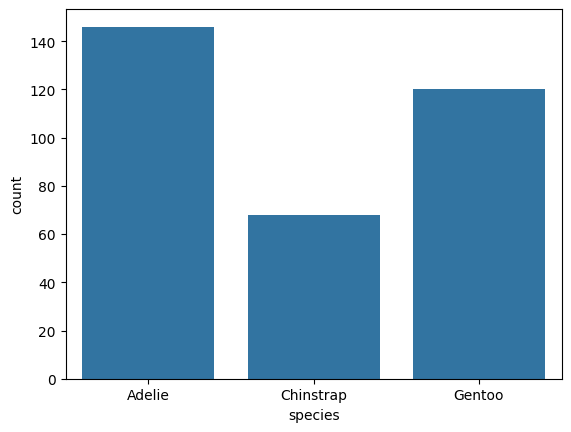

In [150]:
# Species Distribution
sns.countplot(x="species", data=df)
plt.show()

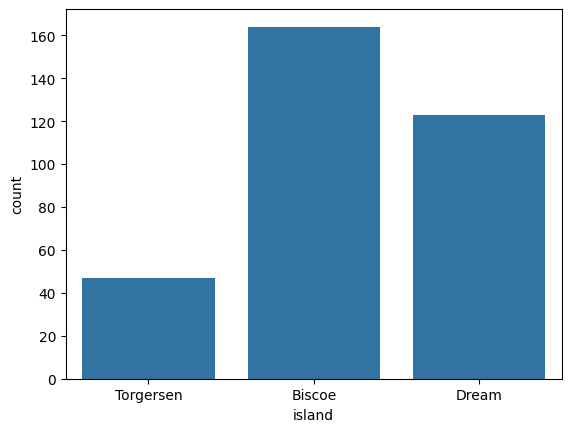

In [151]:
# Island Distribution
sns.countplot(x="island", data=df)
plt.show()

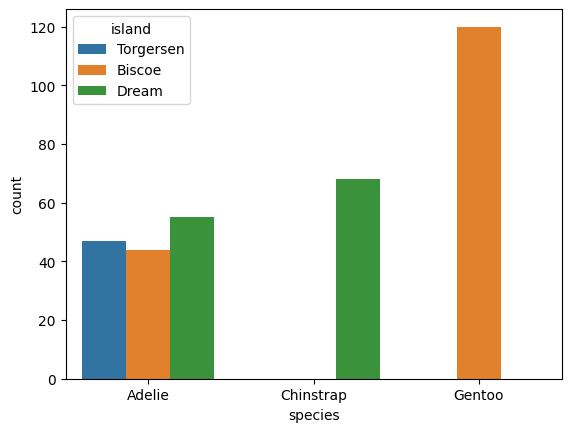

In [152]:
# Species Vs Island
sns.countplot(x="species", hue="island", data=df)
plt.show()

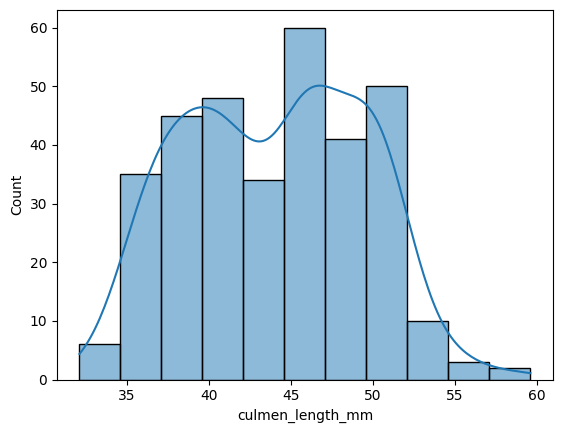

In [153]:
# Culmen Length Distribution
sns.histplot(df["culmen_length_mm"], kde=True)
plt.show()

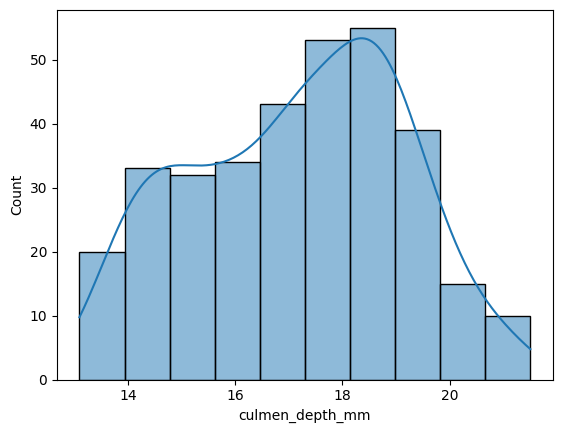

In [154]:
# Culmen Depth Distribution
sns.histplot(df["culmen_depth_mm"], kde=True)
plt.show()

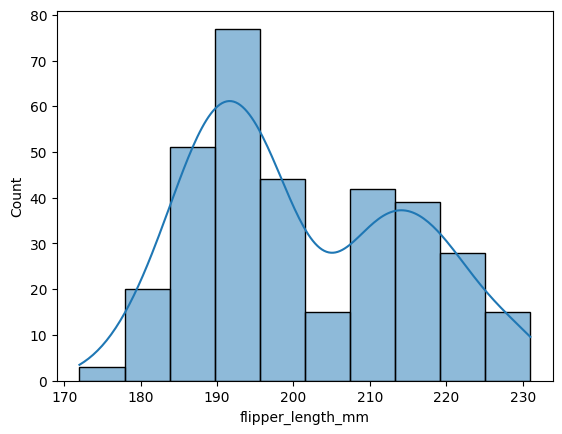

In [155]:
# Flipper Length Distribution
sns.histplot(df["flipper_length_mm"], kde=True)
plt.show()

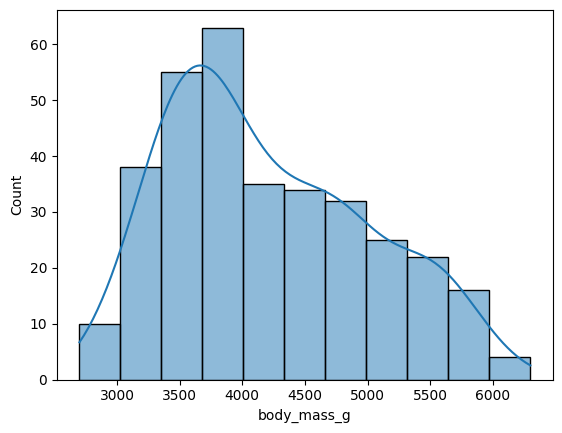

In [156]:
# Body Mass Distribution
sns.histplot(df["body_mass_g"], kde=True)
plt.show()

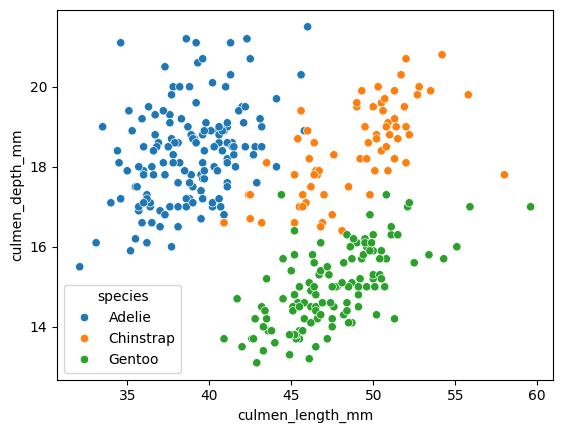

In [157]:
# Culmen Length vs Culmen Depth
sns.scatterplot(x="culmen_length_mm", y="culmen_depth_mm", hue="species", data=df)
plt.show()

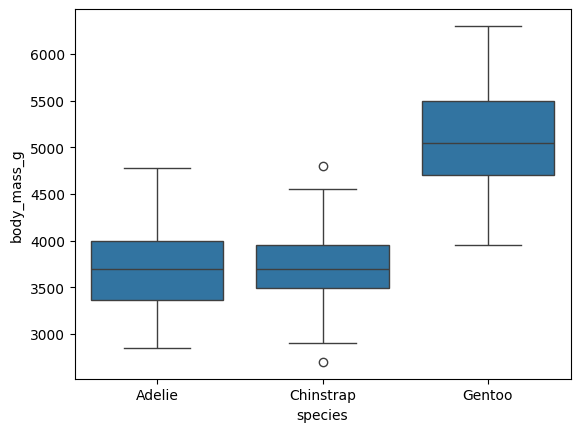

In [158]:
# Species vs Body Mass
sns.boxplot(x="species", y="body_mass_g", data=df)
plt.show()

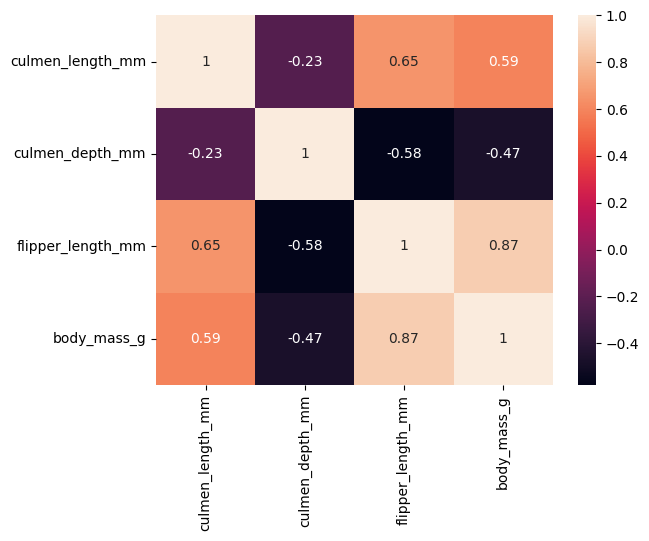

In [159]:
# Correlation Heatmap
sns.heatmap(df.select_dtypes("number").corr(), annot=True)
plt.show()